<a href="https://colab.research.google.com/github/Anand-Ambastha/QSAFIRE/blob/main/osd/preprocessing_pipeline/SNS_TF_QKD_PostProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# SNS-TF-QKD Post Processing Pipeline
### Sending-or-Not-Sending Twin-Field QKD Simulation Data Analysis
Following the security analysis and phase post-selection methodology of
**Wang, Yu & Hu, "Sending or not sending: Twin-field quantum key distribution
with large misalignment error," arXiv:1805.09222v9** (referred to as **Wang et al.** throughout).

**Inputs:** `alice_signal_record.csv`, `bob_signal_record.csv`, `charlie_record_x.csv`,
`charlie_record_z.csv`, `charlie_xbasis_log.csv`

In [ ]:

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 600
DATA_DIR = Path('/content/')
OUT_DIR  = Path('outputs')
(OUT_DIR / 'csv').mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)

F_EC = 1.1

def H(x):.
    x = np.asarray(x, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = -x*np.log2(x) - (1-x)*np.log2(1-x)
    return np.where((x <= 0) | (x >= 1), 0.0, out)


def wilson_ci(k, n, z=1.959963984540054):
    if n == 0:
        return (np.nan, np.nan)
    phat = k/n
    denom = 1 + z**2/n
    center = phat + z**2/(2*n)
    half = z*np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))
    return ((center-half)/denom, (center+half)/denom)



Merge Alice, Bob and Charlie's (X- and Z-detector) records on `Window_Index`, which
uniquely identifies a transmission window, and check for missing windows, duplicate
windows, and basis-label consistency between Alice and Bob.


In [ ]:

alice = pd.read_csv(DATA_DIR / 'alice_signal_record.csv')
bob   = pd.read_csv(DATA_DIR / 'bob_signal_record.csv')
cx    = pd.read_csv(DATA_DIR / 'charlie_record_x.csv')
cz    = pd.read_csv(DATA_DIR / 'charlie_record_z.csv')
cxlog = pd.read_csv(DATA_DIR / 'charlie_xbasis_log.csv')   # optional supplementary log

REQUIRED_AB = ['Window_Index','Selected_Window','Send_Flag','Random_Number','Mu','Decision',
               'Window_Type','Decoy_State','Decoy_Mu','Decoy_Random_Number','P0','P1','P2',
               'Phase_Rad','Phase_Deg','Slice_Number','M']
REQUIRED_C  = ['Window_Index','SPD1','SPD2','Detector','Event']

sync_report = {}
for name, d, req in [('alice',alice,REQUIRED_AB), ('bob',bob,REQUIRED_AB),
                      ('charlie_x',cx,REQUIRED_C), ('charlie_z',cz,REQUIRED_C)]:
    missing_cols = [c for c in req if c not in d.columns]
    sync_report[name] = dict(
        rows=len(d),
        duplicate_window_index=int(d.Window_Index.duplicated().sum()),
        missing_columns=missing_cols,
        null_cells=int(d.isna().sum().sum()),
    )

idx_sets = {n: set(d.Window_Index) for n, d in
            [('alice',alice), ('bob',bob), ('charlie_x',cx), ('charlie_z',cz)]}
common_idx = set.intersection(*idx_sets.values())
union_idx  = set.union(*idx_sets.values())
sync_report['cross_file'] = dict(
    common_windows=len(common_idx),
    union_windows=len(union_idx),
    windows_missing_from_any_file=len(union_idx - common_idx),
)

print("Synchronization report")
for k, v in sync_report.items():
    print(f"  {k}: {v}")

# Merge on Window_Index (inner join on the common index set, which here is the full set)
df = (alice.merge(bob, on='Window_Index', suffixes=('_A', '_B'))
           .merge(cx.rename(columns={'SPD1':'SPD1_X','SPD2':'SPD2_X',
                                      'Detector':'Detector_X','Event':'Event_X'}), on='Window_Index')
           .merge(cz.rename(columns={'SPD1':'SPD1_Z','SPD2':'SPD2_Z',
                                      'Detector':'Detector_Z','Event':'Event_Z'}), on='Window_Index'))
N_total = len(df)

basis_label_agree = (df.Selected_Window_A == df.Selected_Window_B)
print(f"\nTotal synchronized windows: {N_total}")
print(f"Alice/Bob basis-label agreement (both picked the same window type): "
      f"{basis_label_agree.mean():.4f}  ({basis_label_agree.sum()} / {N_total})")
print("Note: Alice and Bob choose decoy/signal windows *independently* in the SNS protocol "
      "(Wang et al., Step 1), so ~50% disagreement is expected, not an error. Windows where "
      "they picked different basis types are 'mismatching windows' (Wang et al., Sec. V-E / "
      "footnote [20]) and are discarded below, exactly as the real protocol discards them.")


Synchronization report
  alice: {'rows': 32768, 'duplicate_window_index': 0, 'missing_columns': [], 'null_cells': 110848}
  bob: {'rows': 32768, 'duplicate_window_index': 0, 'missing_columns': [], 'null_cells': 109408}
  charlie_x: {'rows': 32768, 'duplicate_window_index': 0, 'missing_columns': [], 'null_cells': 0}
  charlie_z: {'rows': 32768, 'duplicate_window_index': 0, 'missing_columns': [], 'null_cells': 0}
  cross_file: {'common_windows': 32768, 'union_windows': 32768, 'windows_missing_from_any_file': 0}

Total synchronized windows: 32768
Alice/Bob basis-label agreement (both picked the same window type): 0.5264  (17248 / 32768)
Note: Alice and Bob choose decoy/signal windows *independently* in the SNS protocol (Wang et al., Step 1), so ~50% disagreement is expected, not an error. Windows where they picked different basis types are 'mismatching windows' (Wang et al., Sec. V-E / footnote [20]) and are discarded below, exactly as the real protocol discards them.



## Basis Separation

Keep only windows where Alice and Bob agree on `Selected_Window`. Split into `X_Basis.csv`
(decoy windows, used for phase post-selection and decoy-state analysis) and `Z_Basis.csv`
(signal windows, used for key generation), matching Wang et al.'s definitions of X-window
and Z-window (Sec. II, Step 1/Sec. V, part A).


In [ ]:

matched = df[basis_label_agree].copy()
X = matched[matched.Selected_Window_A == 'X'].copy()
Z = matched[matched.Selected_Window_A == 'Z'].copy()

X.to_csv(OUT_DIR / 'csv' / 'X_Basis.csv', index=False)
Z.to_csv(OUT_DIR / 'csv' / 'Z_Basis.csv', index=False)

basis_stats = pd.DataFrame({
    'count':       [N_total, len(X), len(Z), N_total-len(matched)],
    'probability': [1.0, len(X)/N_total, len(Z)/N_total, (N_total-len(matched))/N_total],
}, index=['Total windows','X windows (basis-matched)','Z windows (basis-matched)',
          'Mismatched (discarded)'])
basis_stats


,count,probability
Total windows,32768,1.000000
X windows (basis-matched),9536,0.291016
Z windows (basis-matched),7712,0.235352
Mismatched (discarded),15520,0.473633



## X-Basis Phase Post-Selection

**Within X-windows**, Wang et al. require, in addition to both parties choosing a decoy
window, that they used **the same decoy intensity** (Sec. V-A: *"if each of them have sent
out to Charlie a coherent state of the same intensity μₖ it is called an X-window"*).
Windows where Alice and Bob picked different decoy intensities are not true X-windows and
are excluded from phase/decoy analysis (they still exist in the raw data as "mismatching
windows" per footnote [20], useful only for non-asymptotic decoy-state work, which is out
of scope here).

For the intensity-matched, **non-vacuum** X-windows, we apply the phase-matching
acceptance condition, Eq. (1):

$$1 - |\cos(\delta_A - \delta_B)| \le |\lambda|$$

The simulation discretizes phase into `M` slices of width $\Delta = 2\pi/M$
(`Slice_Number = floor(Phase_Rad / Δ) + 1`, verified below). Requiring
`Alice_Slice == Bob_Slice` is the discrete analogue of Eq. (1): two phases in the same bin
satisfy $|\delta_A-\delta_B| < \Delta$, i.e. Eq. (1) holds with
$\lambda_{\text{eff}} = 1-\cos(\Delta)$. We use slice-equality as the operational
acceptance rule and cross-check it against the continuous form of Eq. (1) directly on
`Phase_Rad` for validation.


In [ ]:

M = int(X.M_A.iloc[0])
assert (X.M_A == M).all() and (X.M_B == M).all(), "M must be constant across the dataset"
Delta = 2*np.pi/M
lam_eff = 1 - np.cos(Delta)


computed_slice = np.floor(X.Phase_Rad_A / Delta).astype(int) + 1
slice_formula_ok = (computed_slice == X.Slice_Number_A).mean()
print(f"M = {M}, Delta = 2*pi/M = {Delta:.6f} rad, lambda_eff = 1-cos(Delta) = {lam_eff:.6f}")
print(f"Slice = floor(theta/Delta)+1 formula verified on {slice_formula_ok:.2%} of Alice's X rows")

X['intensity_matched'] = X.Decoy_State_A == X.Decoy_State_B
Xm = X[X.intensity_matched].copy()

print(f"\nX windows (basis-matched):        {len(X)}")
print(f"X windows with matched intensity: {len(Xm)}  "
      f"({len(Xm)/len(X):.2%} of basis-matched X windows)")
print(Xm.Decoy_State_A.value_counts().rename('count').to_frame())

Xnv = Xm[Xm.Decoy_State_A != 'VACUUM'].copy()
Xnv['slice_match'] = Xnv.Slice_Number_A == Xnv.Slice_Number_B

dphi = Xnv.Phase_Rad_A - Xnv.Phase_Rad_B
Xnv['eq1_lhs'] = 1 - np.abs(np.cos(dphi))
Xnv['eq1_criterion'] = Xnv.eq1_lhs <= lam_eff
agree = (Xnv.slice_match == Xnv.eq1_criterion).mean()
print(f"\nAgreement between discrete slice-match rule and continuous Eq.(1) criterion: {agree:.2%}")
print("(Not 100% by construction: two phases can share a slice yet straddle the boundary "
      "relative to lambda_eff, and vice versa near slice edges — an expected discretization "
      "edge effect, not a bug.)")

X_Basis_PhaseMatched = Xnv[Xnv.slice_match].copy()
X_Basis_PhaseMatched = X_Basis_PhaseMatched[
    ['Window_Index','Decoy_State_A','Decoy_Mu_A','Phase_Rad_A','Phase_Rad_B',
     'Slice_Number_A','Slice_Number_B','Detector_X','Event_X']
].rename(columns={'Decoy_State_A':'Decoy_State','Decoy_Mu_A':'Decoy_Mu',
                   'Phase_Rad_A':'Alice_Phase_Rad','Phase_Rad_B':'Bob_Phase_Rad',
                   'Slice_Number_A':'Alice_Slice','Slice_Number_B':'Bob_Slice',
                   'Detector_X':'Detector','Event_X':'Event'})
X_Basis_PhaseMatched['Accepted'] = True
X_Basis_PhaseMatched.to_csv(OUT_DIR / 'csv' / 'X_Basis_PhaseMatched.csv', index=False)

N_X_nonvac = len(Xnv)
N_accepted = len(X_Basis_PhaseMatched)
P_acc = N_accepted / N_X_nonvac
ci_lo, ci_hi = wilson_ci(N_accepted, N_X_nonvac)
print(f"\nNon-vacuum, intensity-matched X windows: {N_X_nonvac}")
print(f"Phase-matched (accepted):                {N_accepted}")
print(f"Rejected:                                {N_X_nonvac - N_accepted}")
print(f"P_acc = N_accepted / N_X = {P_acc:.4f}   (95% Wilson CI: [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"Theoretical random-phase expectation ~= 1/M = {1/M:.4f}  (consistency check)")


M = 16, Delta = 2*pi/M = 0.392699 rad, lambda_eff = 1-cos(Delta) = 0.076120
Slice = floor(theta/Delta)+1 formula verified on 100.00% of Alice's X rows

X windows (basis-matched):        9536
X windows with matched intensity: 3464  (36.33% of basis-matched X windows)
               count
Decoy_State_A       
DECOY_2         1566
DECOY_1         1519
VACUUM           379

Agreement between discrete slice-match rule and continuous Eq.(1) criterion: 80.91%
(Not 100% by construction: two phases can share a slice yet straddle the boundary relative to lambda_eff, and vice versa near slice edges — an expected discretization edge effect, not a bug.)

Non-vacuum, intensity-matched X windows: 3085
Phase-matched (accepted):                215
Rejected:                                2870
P_acc = N_accepted / N_X = 0.0697   (95% Wilson CI: [0.0612, 0.0792])
Theoretical random-phase expectation ~= 1/M = 0.0625  (consistency check)



##  X-Basis Detection Analysis

Detector-click statistics on the phase-matched X events, and the X-basis gain

$$Q_X = \frac{N_{\text{click}}}{N_{\text{accepted}}}$$

An *effective event*, per Wang et al.'s definition just above Eq. (1), requires **exactly
one** detector to click (`D1_CLICK` or `D2_CLICK`); `DOUBLE_CLICK` and `NO_CLICK` are not
effective events and do not contribute to the gain numerator.


In [ ]:

ev = X_Basis_PhaseMatched.Event
det_counts = ev.value_counts().reindex(['D1_CLICK','D2_CLICK','DOUBLE_CLICK','NO_CLICK']).fillna(0).astype(int)
print("Detector-event counts on phase-matched X events:")
print(det_counts.to_frame('count'))

N_click_X = int(det_counts['D1_CLICK'] + det_counts['D2_CLICK'])
Q_X = N_click_X / N_accepted if N_accepted else np.nan
ci_lo, ci_hi = wilson_ci(N_click_X, N_accepted)
print(f"\nN_click (single-detector clicks) = {N_click_X}")
print(f"Q_X = N_click / N_accepted = {Q_X:.4f}   (95% Wilson CI: [{ci_lo:.4f}, {ci_hi:.4f}])")

cosdiff = np.cos(X_Basis_PhaseMatched.Bob_Phase_Rad - X_Basis_PhaseMatched.Alice_Phase_Rad)
click_mask = ev.isin(['D1_CLICK','D2_CLICK'])
error_mask = ((ev == 'D1_CLICK') & (cosdiff < 0)) | ((ev == 'D2_CLICK') & (cosdiff >= 0))
n_click, n_err = int(click_mask.sum()), int(error_mask.sum())
E_X = n_err / n_click if n_click else np.nan
ci_lo, ci_hi = wilson_ci(n_err, n_click)
print(f"\nE_X (X-basis detector error rate) = {n_err}/{n_click} = {E_X:.4f}   "
      f"(95% Wilson CI: [{ci_lo:.4f}, {ci_hi:.4f}])")
print("(This is on a small sample — see the Conclusion for a caveat on statistical power.)")


Detector-event counts on phase-matched X events:
              count
Event              
D1_CLICK         21
D2_CLICK         22
DOUBLE_CLICK      6
NO_CLICK        166

N_click (single-detector clicks) = 43
Q_X = N_click / N_accepted = 0.2000   (95% Wilson CI: [0.1520, 0.2585])

E_X (X-basis detector error rate) = 22/43 = 0.5116   (95% Wilson CI: [0.3675, 0.6538])
(This is on a small sample — see the Conclusion for a caveat on statistical power.)



##Decoy-State Yields and Phase-Error Estimation

Wang et al.'s decoy-state analysis (Sec. V, Note 2 of Virtual Protocol 3) is run on the
**click rate among all intensity-matched X-windows at each intensity level**
(vacuum, and the two non-zero decoy intensities), *not* restricted to the phase-matched
subset — the click rate of a phase-randomized coherent state is independent of the
announced phase, which is exactly the fact that lets the traditional decoy-state formulas
apply directly to this protocol (that is the paper's central point in Sec. IV).

Two-mode (X-window) photon-number probabilities, Eqs. (6), (8), (9):

$$p_0(\mu)=e^{-2\mu},\qquad p_1(\mu)=2\mu e^{-2\mu},\qquad p_2(\mu)=2\mu^2 e^{-2\mu}$$

Single-photon yield lower bound, Eq. (44) (three intensities $\mu_0=0<\mu_1<\mu_2$):

$$\underline{s_1} = \frac{p_2(\mu_2)\big(S_{\mu_1}-p_0(\mu_1)s_0\big) - p_2(\mu_1)\big(S_{\mu_2}-p_0(\mu_2)s_0\big)}
{p_2(\mu_2)p_1(\mu_1) - p_2(\mu_1)p_1(\mu_2)}$$

Phase-flip error rate upper bound, Eq. (45):

$$e_1^{ph} \le \bar e_1^{ph} = \frac{S_{\mu_1}E^X_{\mu_1} - e^{-2\mu_1}s_0/2}{2\mu_1 e^{-2\mu_1}s_1}$$

Here $Y_0 \equiv s_0$ (the vacuum click/yield rate) and $Y_1 \equiv s_1$ (the estimated
single-photon yield) in the notation used by Step 8 of the original specification — Wang et
al. use $s_0, s_1$ throughout, so we keep that notation and note the $Y_0,Y_1$ aliases
explicitly.


In [ ]:

def p_k(mu, k):
    if k == 0: return np.exp(-2*mu)
    if k == 1: return 2*mu*np.exp(-2*mu)
    if k == 2: return 2*mu**2*np.exp(-2*mu)
    raise ValueError(k)

def click_rate(sub):
    ev = sub.Event_X
    n_click = ev.isin(['D1_CLICK','D2_CLICK']).sum()
    return (n_click/len(sub) if len(sub) else np.nan), len(sub), int(n_click)

levels = {}
for state in ['VACUUM','DECOY_1','DECOY_2']:
    sub = Xm[Xm.Decoy_State_A == state]
    mu = sub.Decoy_Mu_A.iloc[0] if len(sub) else np.nan
    S, N, k = click_rate(sub)
    levels[state] = dict(mu=mu, S=S, N=N, k=k)

level_table = pd.DataFrame(levels).T
level_table.index.name = 'Decoy_State'
print("Per-intensity X_mu window statistics (all intensity-matched X windows, any phase):")
level_table

mu0, s0 = levels['VACUUM']['mu'], levels['VACUUM']['S']
lo_key, hi_key = (('DECOY_1','DECOY_2') if levels['DECOY_1']['mu'] < levels['DECOY_2']['mu']
                   else ('DECOY_2','DECOY_1'))
mu1, mu2 = levels[lo_key]['mu'], levels[hi_key]['mu']
S_mu1, S_mu2 = levels[lo_key]['S'], levels[hi_key]['S']
assert mu0 == 0, "Eq.(44)/(45) assume the vacuum intensity is exactly 0"

# Eq.(44): single-photon yield lower bound
num = p_k(mu2,2)*(S_mu1 - p_k(mu1,0)*s0) - p_k(mu1,2)*(S_mu2 - p_k(mu2,0)*s0)
den = p_k(mu2,2)*p_k(mu1,1) - p_k(mu1,2)*p_k(mu2,1)
s1 = num/den
Y0, Y1 = s0, s1


sub_mu1_pm = X_Basis_PhaseMatched[X_Basis_PhaseMatched.Decoy_State == lo_key]
cosdiff1 = np.cos(sub_mu1_pm.Bob_Phase_Rad - sub_mu1_pm.Alice_Phase_Rad)
ev1 = sub_mu1_pm.Event
err1_mask = ((ev1 == 'D1_CLICK') & (cosdiff1 < 0)) | ((ev1 == 'D2_CLICK') & (cosdiff1 >= 0))
click1_mask = ev1.isin(['D1_CLICK','D2_CLICK'])
n_click1, n_err1 = int(click1_mask.sum()), int(err1_mask.sum())
E_X_mu1 = n_err1/n_click1 if n_click1 else np.nan

# Eq.(45)
e1_ph = (S_mu1*E_X_mu1 - np.exp(-2*mu1)*s0/2) / (2*mu1*np.exp(-2*mu1)*s1)

print(f"\nmu0 (vacuum) = {mu0}, mu1 = {mu1} ({lo_key}), mu2 = {mu2} ({hi_key})")
print(f"S_mu1 = {S_mu1:.4f} (n={levels[lo_key]['N']}), S_mu2 = {S_mu2:.4f} (n={levels[hi_key]['N']}), s0 = {s0:.4f} (n={levels['VACUUM']['N']})")
print(f"\n s1 = Y1 = {s1:.4f}   (Eq. 44)")
print(f"s0 = Y0 = {s0:.4f}   (vacuum click rate)")
print(f"E^X_mu1 (phase-matched click error at mu1) = {n_err1}/{n_click1} = {E_X_mu1:.4f}")
print(f"Step 5 result — e1_ph (phase-error upper bound) = {e1_ph:.4f}   (Eq. 45)")
if not (0 <= s1 <= 1):
    print("\n** WARNING: s1 fell outside [0,1] — the decoy-state bound is not physical here; "
          "this happens when the click-rate statistics are noisy/inconsistent across "
          "intensities (small-sample or non-physical-channel data). Reported as-is.")
if not (0 <= e1_ph <= 1):
    print("** WARNING: e1_ph fell outside [0,1] for the same reason — reported as-is, "
          "clipped to [0,1] only where used inside H(.) below (H is defined as 0 outside [0,1]).")


Per-intensity X_mu window statistics (all intensity-matched X windows, any phase):

mu0 (vacuum) = 0.0, mu1 = 0.05 (DECOY_1), mu2 = 0.2 (DECOY_2)
S_mu1 = 0.1824 (n=1519), S_mu2 = 0.2043 (n=1566), s0 = 0.1900 (n=379)

Step 5/8 result — s1 = Y1 = 0.0584   (Eq. 44)
Step 5/8 result — s0 = Y0 = 0.1900   (vacuum click rate)
E^X_mu1 (phase-matched click error at mu1) = 8/18 = 0.4444
Step 5 result — e1_ph (phase-error upper bound) = -0.9268   (Eq. 45)
** WARNING: e1_ph fell outside [0,1] for the same reason — reported as-is, clipped to [0,1] only where used inside H(.) below (H is defined as 0 outside [0,1]).



## Z-Basis Processing: SNS Categories

Every Z-window falls into one of four categories based on Alice's and Bob's independent
sending decisions (Wang et al., Step 0/Note under Step 4): both send, both not-send
(these two produce Z-basis bit errors whenever an effective event occurs — see Step 7),
Alice-sends-Bob-doesn't, or Bob-sends-Alice-doesn't (these are the "Z1-window" categories
that carry genuine key bits).


In [ ]:

cat = pd.Series('other', index=Z.index, dtype='object')
cat[(Z.Decision_A=='SEND') & (Z.Decision_B=='NOT_SEND')] = 'Alice_sends_Bob_not'
cat[(Z.Decision_A=='NOT_SEND') & (Z.Decision_B=='SEND')] = 'Bob_sends_Alice_not'
cat[(Z.Decision_A=='SEND') & (Z.Decision_B=='SEND')]     = 'both_send'
cat[(Z.Decision_A=='NOT_SEND') & (Z.Decision_B=='NOT_SEND')] = 'both_not_send'
Z['SNS_category'] = cat

sns_counts = Z.SNS_category.value_counts().reindex(
    ['Alice_sends_Bob_not','Bob_sends_Alice_not','both_send','both_not_send'])
sns_table = sns_counts.to_frame('count')
sns_table['probability'] = sns_table['count'] / len(Z)
sns_table


,count,probability
SNS_category,,
Alice_sends_Bob_not,1583,0.205265
Bob_sends_Alice_not,1635,0.212007
both_send,664,0.086100
both_not_send,3830,0.496629







## Gain and QBER (Z-basis)

$$Q_Z = \frac{N_{\text{click}}}{N_Z}, \qquad
\text{QBER} = E^Z = \frac{N_{\text{error}}}{N_{\text{click}}}$$

An error bit in Z-basis occurs, per Wang et al.'s Note under Step 4, exactly when an
effective (single-detector) event happens **while both parties made the same
send/not-send decision** (`both_send` or `both_not_send`) — in those cases Alice's and
Bob's bit-value conventions necessarily disagree.


In [ ]:

ev_z = Z.Event_Z
click_mask_z = ev_z.isin(['D1_CLICK','D2_CLICK'])
N_click_Z = int(click_mask_z.sum())
Q_Z = N_click_Z/len(Z)
ci_lo, ci_hi = wilson_ci(N_click_Z, len(Z))
print(f"N_Z = {len(Z)}, N_click = {N_click_Z}")
print(f"Q_Z = {Q_Z:.4f}   (95% Wilson CI: [{ci_lo:.4f}, {ci_hi:.4f}])")

err_mask_z = click_mask_z & Z.SNS_category.isin(['both_send','both_not_send'])
N_err_Z = int(err_mask_z.sum())
QBER = N_err_Z/N_click_Z if N_click_Z else np.nan
ci_lo, ci_hi = wilson_ci(N_err_Z, N_click_Z)
print(f"\nN_error = {N_err_Z}, N_click = {N_click_Z}")
print(f"QBER = E^Z = {QBER:.4f}   (95% Wilson CI: [{ci_lo:.4f}, {ci_hi:.4f}])")

z_detector_table = Z.groupby('SNS_category').Event_Z.value_counts().unstack(fill_value=0)
z_detector_table = z_detector_table.reindex(
    ['Alice_sends_Bob_not','Bob_sends_Alice_not','both_send','both_not_send'])
z_detector_table


N_Z = 7712, N_click = 1458
Q_Z = 0.1891   (95% Wilson CI: [0.1805, 0.1979])

N_error = 861, N_click = 1458
QBER = E^Z = 0.5905   (95% Wilson CI: [0.5651, 0.6155])


Event_Z,D1_CLICK,D2_CLICK,DOUBLE_CLICK,NO_CLICK
SNS_category,,,,
Alice_sends_Bob_not,110,170,27,1276
Bob_sends_Alice_not,136,181,21,1297
both_send,64,78,10,512
both_not_send,311,408,86,3025



## Secret Key Rate

We use Wang et al.'s **per-time-window key-rate formula, Eq. (4)**, which is algebraically
equivalent to the bit-count formula Eq. (3) but works directly off the observed rates
computed above (no need to separately reconstruct $n_1$, $n_t$):

$$R = 2\epsilon(1-\epsilon)\,\mu' e^{-\mu'} s_1\big(1-H(e_1^{ph})\big) \;-\; S_Z\, f\, H(E^Z)$$

where:
- $\epsilon$ = probability of choosing "send" in a signal (Z) window, averaged over Alice
  and Bob's observed empirical rates,
- $\mu'$ = the mean signal-pulse intensity actually used on "send" decisions,
- $s_1$ = the single-photon yield from Step 5 (Eq. 44),
- $e_1^{ph}$ = the phase-error upper bound from Step 5 (Eq. 45),
- $S_Z = Q_Z$ = the observed Z-window counting (click) rate from Step 7,
- $f=1.1$ = the error-correction inefficiency factor (Sec. III),
- $E^Z$ = QBER from Step 7.

For cross-reference we also report the equivalent bit-count form, Eq. (3):
$N_f = n_1 - n_1 H(e_1^{ph}) - n_t f H(E^Z)$, using $n_1 \approx s_1 \cdot p_1(\mu')\cdot N_{Z1}$
(single-mode Poisson single-photon probability $p_1(\mu')=\mu' e^{-\mu'}$ applied to the
count of Z1-type windows) and $n_t = N_{\text{click},Z}$.


In [ ]:

eps_A = (Z.Decision_A == 'SEND').mean()
eps_B = (Z.Decision_B == 'SEND').mean()
eps = (eps_A + eps_B) / 2
mu_prime = Z.loc[Z.Decision_A == 'SEND', 'Mu_A'].mean()

S_Z = Q_Z
e1_ph_clipped = float(np.clip(e1_ph, 0, 1))
QBER_clipped  = float(np.clip(QBER, 0, 1))

R = 2*eps*(1-eps) * mu_prime*np.exp(-mu_prime) * s1 * (1 - H(e1_ph_clipped)) - S_Z*F_EC*H(QBER_clipped)

print("Constituent terms")
print(f"  epsilon (Alice/Bob avg 'send' probability) = {eps:.4f}  (Alice: {eps_A:.4f}, Bob: {eps_B:.4f})")
print(f"  mu' (mean signal intensity on send)        = {mu_prime:.6e}")
print(f"  s1 (single-photon yield, Eq.44)             = {s1:.4f}")
print(f"  e1_ph (phase-error bound, Eq.45)             = {e1_ph:.4f}  (clipped to {e1_ph_clipped:.4f} for H(.))")
print(f"  H(e1_ph)                                     = {H(e1_ph_clipped):.4f}")
print(f"  S_Z = Q_Z                                    = {S_Z:.4f}")
print(f"  QBER = E^Z                                   = {QBER:.4f}  (clipped to {QBER_clipped:.4f} for H(.))")
print(f"  H(E^Z)                                        = {H(QBER_clipped):.4f}")
print(f"  f (error-correction factor)                  = {F_EC}")
print(f"\nSecret key rate per time-window pair, R (Eq. 4) = {R:.6f}")

# --- supplementary bit-count cross-check, Eq. (3) ---
N_Z1 = int(Z.SNS_category.isin(['Alice_sends_Bob_not','Bob_sends_Alice_not']).sum())
p1_mu_prime = mu_prime * np.exp(-mu_prime)          # single-mode Poisson P(1 photon | mu')
n1_est = s1 * p1_mu_prime * N_Z1
n_t = N_click_Z
Nf = n1_est - n1_est*H(e1_ph_clipped) - n_t*F_EC*H(QBER_clipped)

print("\nSupplementary bit-count cross-check (Eq. 3)")
print(f"  N_Z1 (Alice-or-Bob-only-sends windows) = {N_Z1}")
print(f"  p1(mu') = mu' * exp(-mu')                = {p1_mu_prime:.6e}")
print(f"  n1 (estimated Z1-bits)                   = {n1_est:.4f}")
print(f"  n_t (total effective Z-basis events)      = {n_t}")
print(f"  Nf (final bits, Eq. 3)                    = {Nf:.4f}")
print(f"  Nf / N_total  (~ per-window rate, should match R above)  = {Nf/N_total:.6f}  vs R = {R:.6f}")


Constituent terms
  epsilon (Alice/Bob avg 'send' probability) = 0.2947  (Alice: 0.2914, Bob: 0.2981)
  mu' (mean signal intensity on send)        = 1.000000e-01
  s1 (single-photon yield, Eq.44)             = 0.0584
  e1_ph (phase-error bound, Eq.45)             = -0.9268  (clipped to 0.0000 for H(.))
  H(e1_ph)                                     = 0.0000
  S_Z = Q_Z                                    = 0.1891
  QBER = E^Z                                   = 0.5905  (clipped to 0.5905 for H(.))
  H(E^Z)                                        = 0.9762
  f (error-correction factor)                  = 1.1

Secret key rate per time-window pair, R (Eq. 4) = -0.200818

Supplementary bit-count cross-check (Eq. 3)
  N_Z1 (Alice-or-Bob-only-sends windows) = 3218
  p1(mu') = mu' * exp(-mu')                = 9.048374e-02
  n1 (estimated Z1-bits)                   = 17.0144
  n_t (total effective Z-basis events)      = 1458
  Nf (final bits, Eq. 3)                    = -1548.6451
  Nf / N_total 


## Consolidated Statistics Tables


In [ ]:

basis_stats_tbl = pd.DataFrame({
    'count': [N_total, len(X), len(Z)],
    'probability': [1.0, len(X)/N_total, len(Z)/N_total],
}, index=['Total (basis-matched+mismatched)','X windows','Z windows'])

phase_stats_tbl = pd.DataFrame({
    'count': [N_X_nonvac, N_accepted, N_X_nonvac-N_accepted],
    'fraction_of_X_nonvac': [1.0, P_acc, 1-P_acc],
}, index=['Non-vacuum intensity-matched X windows','Phase-matched (accepted)','Rejected'])

slice_occ_alice = Xnv.Slice_Number_A.value_counts().sort_index()
slice_occ_bob   = Xnv.Slice_Number_B.value_counts().sort_index()

detector_stats_tbl = det_counts.to_frame('phase_matched_X_events')

security_stats_tbl = pd.DataFrame({
    'value': [Q_X, E_X, Q_Z, QBER, s0, s1, e1_ph, R],
}, index=['Q_X (X-basis gain)','E_X (X-basis error rate)','Q_Z (Z-basis gain)',
          'QBER = E^Z (Z-basis error rate)','s0 = Y0 (vacuum yield)','s1 = Y1 (single-photon yield)',
          'e1_ph (phase-error bound)','R (secret key rate / window, Eq.4)'])

print("Basis statistics"); display(basis_stats_tbl)
print("\nPhase statistics"); display(phase_stats_tbl)
print("\nSlice occupancy (Alice, non-vacuum X windows)"); display(slice_occ_alice.to_frame('count'))
print("\nDetector statistics (phase-matched X events)"); display(detector_stats_tbl)
print("\nSecurity statistics"); display(security_stats_tbl)


=== Basis statistics ===


,count,probability
Total (basis-matched+mismatched),32768,1.000000
X windows,9536,0.291016
Z windows,7712,0.235352



=== Phase statistics ===


,count,fraction_of_X_nonvac
Non-vacuum intensity-matched X windows,3085,1.000000
Phase-matched (accepted),215,0.069692
Rejected,2870,0.930308



=== Slice occupancy (Alice, non-vacuum X windows) ===


,count
Slice_Number_A,
1,195
2,166
3,194
4,189
5,212
6,198
7,218
8,192
9,189



=== Detector statistics (phase-matched X events) ===


,phase_matched_X_events
Event,
D1_CLICK,21
D2_CLICK,22
DOUBLE_CLICK,6
NO_CLICK,166



=== Security statistics ===


,value
Q_X (X-basis gain),0.200000
E_X (X-basis error rate),0.511628
Q_Z (Z-basis gain),0.189056
QBER = E^Z (Z-basis error rate),0.590535
s0 = Y0 (vacuum yield),0.189974
s1 = Y1 (single-photon yield),0.058433
e1_ph (phase-error bound),-0.926781
"R (secret key rate / window, Eq.4)",-0.200818



## Visualization


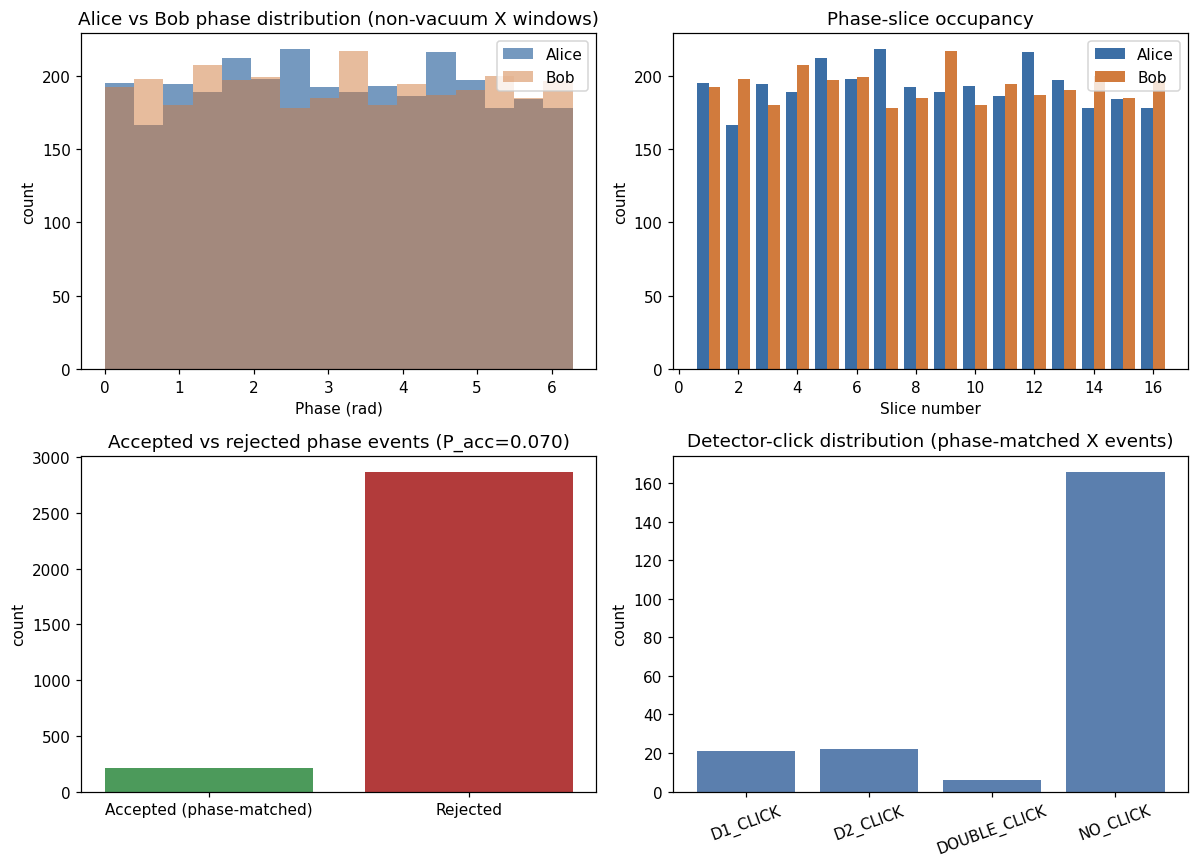

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0,0].hist(Xnv.Phase_Rad_A, bins=M, range=(0, 2*np.pi), alpha=0.7, label="Alice", color='#3b6ea5')
axes[0,0].hist(Xnv.Phase_Rad_B, bins=M, range=(0, 2*np.pi), alpha=0.5, label="Bob", color='#d17b3d')
axes[0,0].set_title('Alice vs Bob phase distribution (non-vacuum X windows)')
axes[0,0].set_xlabel('Phase (rad)'); axes[0,0].set_ylabel('count'); axes[0,0].legend()

slice_idx = np.arange(1, M+1)
axes[0,1].bar(slice_idx-0.2, slice_occ_alice.reindex(slice_idx, fill_value=0), width=0.4, label='Alice', color='#3b6ea5')
axes[0,1].bar(slice_idx+0.2, slice_occ_bob.reindex(slice_idx, fill_value=0), width=0.4, label='Bob', color='#d17b3d')
axes[0,1].set_title('Phase-slice occupancy'); axes[0,1].set_xlabel('Slice number'); axes[0,1].set_ylabel('count')
axes[0,1].legend()

axes[1,0].bar(['Accepted (phase-matched)','Rejected'], [N_accepted, N_X_nonvac-N_accepted],
              color=['#4c9a5b','#b23b3b'])
axes[1,0].set_title(f'Accepted vs rejected phase events (P_acc={P_acc:.3f})')
axes[1,0].set_ylabel('count')

det_labels = ['D1_CLICK','D2_CLICK','DOUBLE_CLICK','NO_CLICK']
axes[1,1].bar(det_labels, det_counts.reindex(det_labels), color='#5b7fae')
axes[1,1].set_title('Detector-click distribution (phase-matched X events)')
axes[1,1].set_ylabel('count')
for ax in axes[1,1],:
    ax.tick_params(axis='x', rotation=20)

fig.tight_layout()
fig.savefig(OUT_DIR / 'figures' / 'phase_and_detector_analysis.png', dpi=150)
fig.savefig(OUT_DIR / 'figures' / 'phase_and_detector_analysis.pdf')
plt.show()


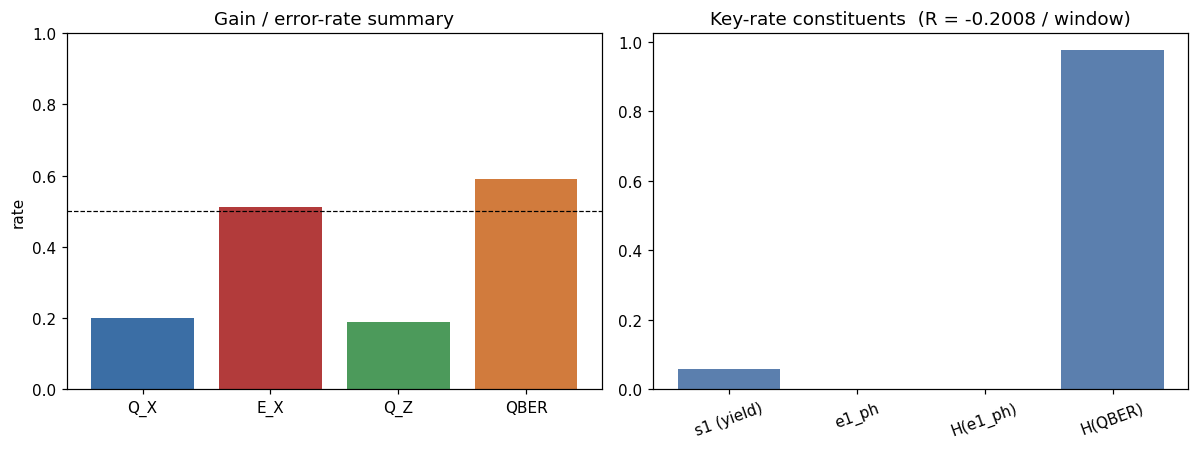

In [ ]:

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.2))

metrics = ['Q_X','E_X','Q_Z','QBER']
values  = [Q_X, E_X, Q_Z, QBER]
axes2[0].bar(metrics, values, color=['#3b6ea5','#b23b3b','#4c9a5b','#d17b3d'])
axes2[0].axhline(0.5, color='k', linewidth=0.8, linestyle='--')
axes2[0].set_ylim(0, 1)
axes2[0].set_title('Gain / error-rate summary')
axes2[0].set_ylabel('rate')

key_terms = ['s1 (yield)', 'e1_ph', 'H(e1_ph)', 'H(QBER)']
key_vals  = [s1, e1_ph_clipped, H(e1_ph_clipped), H(QBER_clipped)]
axes2[1].bar(key_terms, key_vals, color='#5b7fae')
axes2[1].set_title(f'Key-rate constituents  (R = {R:.4f} / window)')
axes2[1].tick_params(axis='x', rotation=20)

fig2.tight_layout()
fig2.savefig(OUT_DIR / 'figures' / 'security_metrics_summary.png', dpi=150)
fig2.savefig(OUT_DIR / 'figures' / 'security_metrics_summary.pdf')
plt.show()
